In [1]:
import numpy as np
import pandas as pd

import regreg.api as rr
from selectinf.lasso import lasso
from selectinf.Utils.base import selected_targets, selected_targets_logistic, restricted_estimator

import warnings
# suppress warnings
warnings.filterwarnings('ignore')

In [2]:
def logistic_instance(n=300, p=40, s=6, beta_scale=1.5, seed=0, with_intercept=True):
    """
    Simple logistic simulation:
      y ~ Bernoulli(sigmoid(X beta))
    Returns X, y, beta_true.
    """
    rng = np.random.default_rng(seed)

    X = rng.standard_normal((n, p))
    X -= X.mean(axis=0)
    X /= (X.std(axis=0) + 1e-12)

    beta = np.zeros(p)
    beta[:s] = beta_scale * rng.choice([-1.0, 1.0], size=s)

    eta = X @ beta
    pr = 1.0 / (1.0 + np.exp(-eta))
    y = rng.binomial(1, pr, size=n).astype(float)

    if with_intercept:
        X = np.column_stack([np.ones(n), X])
        beta = np.concatenate([[0.0], beta])

    return X, y, beta

In [3]:
def randomized_logistic_lasso_pivot_demo(
    n=300,
    p=40,
    s=6,
    beta_scale=5,
    seed=0,
    randomizer_scale=1.0,
    ridge_term=0.0,
):
    """
    End-to-end:
      1) simulate logistic data
      2) choose a lambda (feature_weights) similar to the Gaussian test heuristic
      3) randomized logistic lasso selection
      4) exact/pivot-based selective inference on selected targets
    """
    # -----------------------
    # 1) data
    # -----------------------
    X, y, beta_true = logistic_instance(
        n=n, p=p, s=s, beta_scale=beta_scale, seed=seed, with_intercept=False
    )
    print(beta_true)
    n, p_plus = X.shape

    # -----------------------
    # 2) penalty weights (lambda)
    # -----------------------
    rng = np.random.default_rng(seed + 1)
    eps = rng.standard_normal((n, 2000))
    W = 0.4 * np.median(np.abs(X.T @ eps).max(axis=1))

    feature_weights = W * np.ones(p_plus)

    # -----------------------
    # 3) randomized logistic lasso
    # -----------------------
    const = lasso.logistic
    conv = const(
        X,
        y,                  # successes (0/1)
        feature_weights,
        ridge_term=ridge_term,
        randomizer_scale=randomizer_scale,
    )

    signs = conv.fit()
    nonzero = signs != 0
    # nonzero[0] = False

    active = np.where(nonzero)[0]

    print(f"Selected {nonzero.sum()} variables")
    print("Active indices:", active.tolist())

    if nonzero.sum() == 0:
        return None

    # -----------------------
    # 4) inference (pivot-based)
    # -----------------------
    # Logistic has no free dispersion parameter in the canonical GLM
    dispersion = 1.0
    conv.setup_inference(dispersion=dispersion)

    # Target specification: "selected_targets" is the direct analogue
    # of what we do for Gaussian.

    # target_spec = selected_targets(
    #     conv.loglike,
    #     conv.observed_soln,
    #     dispersion=dispersion,
    # )
    #
    # result = conv.inference(target_spec)

    target_spec = selected_targets_logistic(
        conv.loglike,
        conv.observed_soln,
        K = conv.K,
        dispersion=1.0,
    )

    result = conv.inference(target_spec)

    show_cols = [c for c in [
        "target", "pvalue", "lower_confidence", "upper_confidence"
    ] if c in result.columns]

    print("\nSelective inference results (subset of columns):")
    print(result[show_cols])

    return result


if __name__ == "__main__":
    randomized_logistic_lasso_pivot_demo(
        n=300,
        p=40,
        s=6,
        beta_scale=1.5,
        seed=0,
        randomizer_scale=1.0,
        ridge_term=0.0,
    )


[-1.5 -1.5 -1.5 -1.5 -1.5  1.5  0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
Selected 6 variables
Active indices: [0, 1, 2, 3, 4, 5]

Selective inference results (subset of columns):
     target        pvalue  lower_confidence  upper_confidence
0 -1.906364  2.014973e-04         -2.458886         -0.994356
1 -1.899309  1.362635e-07         -2.467428         -1.329609
2 -1.655249  8.735640e-04         -2.189109         -0.800194
3 -1.623023  5.440851e-01         -1.098786          0.509847
4 -2.772873  3.147366e-09         -3.542802         -2.002945
5  1.658076  1.684629e-04          0.948880          2.209187


Rep 1: selected=6, coverage=1.000, length=0.796
Rep 2: selected=6, coverage=1.000, length=0.868
Rep 3: selected=6, coverage=1.000, length=0.739
Rep 4: selected=6, coverage=0.667, length=0.716
Rep 5: selected=6, coverage=1.000, length=0.766
Rep 6: selected=6, coverage=0.833, length=0.647
Rep 7: selected=6, coverage=1.000, length=0.638
Rep 8: selected=6, coverage=0.833, length=0.648
Rep 9: selected=6, coverage=0.833, length=0.975
Rep 10: selected=6, coverage=0.667, length=0.863
Rep 11: selected=6, coverage=1.000, length=0.628
Rep 12: selected=6, coverage=1.000, length=0.635
Rep 13: selected=6, coverage=1.000, length=0.759
Rep 14: selected=6, coverage=0.833, length=0.702
Rep 15: selected=6, coverage=1.000, length=0.706
Rep 16: selected=6, coverage=1.000, length=0.776
Rep 17: selected=6, coverage=1.000, length=0.743
Rep 18: selected=6, coverage=1.000, length=0.747
Rep 19: selected=6, coverage=1.000, length=0.635
Rep 20: selected=6, coverage=1.000, length=0.687
Rep 21: selected=6, coverage=

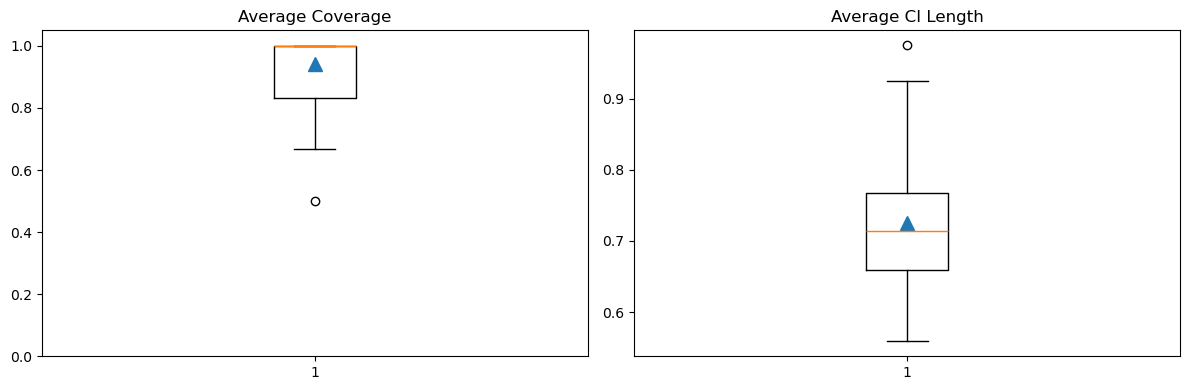

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def selective_logistic_lasso_simulation(
    nrep=100,
    n=300,
    p=40,
    s=6,
    beta_scale=5,
    seed=0,
    randomizer_scale=1.0,
    ridge_term=0.0,
):

    avg_coverage_list = []
    avg_length_list = []
    n_selected_list = []

    for rep in range(nrep):

        rng_seed = seed + rep

        # -----------------------
        # simulate data
        # -----------------------
        X, y, beta_true = logistic_instance(
            n=n,
            p=p,
            s=s,
            beta_scale=beta_scale,
            seed=rng_seed,
            with_intercept=False
        )

        n_obs, p_plus = X.shape


        # -----------------------
        # lambda choice
        # -----------------------
        rng = np.random.default_rng(rng_seed + 1)

        eps = rng.standard_normal((n_obs, 2000))

        W = 0.4 * np.median(np.abs(X.T @ eps).max(axis=1))

        feature_weights = W * np.ones(p_plus)


        # -----------------------
        # randomized logistic lasso
        # -----------------------
        conv = lasso.logistic(
            X,
            y,
            feature_weights,
            ridge_term=ridge_term,
            randomizer_scale=randomizer_scale,
        )

        signs = conv.fit()

        nonzero = signs != 0

        active = np.where(nonzero)[0]

        if len(active) == 0:
            continue


        # -----------------------
        # selective inference
        # -----------------------
        dispersion=1
        # dispersion= np.mean()
        conv.setup_inference(dispersion=dispersion)

        target_spec = selected_targets_logistic(
            conv.loglike,
            conv.observed_soln,
            K=conv.K,
            dispersion=dispersion
        )

        result_exact = conv.inference(target_spec)


        # -----------------------
        # extract intervals
        # -----------------------
        intervals = np.asarray(
            result_exact[['lower_confidence', 'upper_confidence']]
        )

        lci = intervals[:, 0]
        uci = intervals[:, 1]


        # beta_target = beta_true[active]

        Y_mean = 1 / (1 + np.exp(-X.dot(beta_true)))

        loglike = rr.glm.logistic(X, successes=Y_mean, trials=np.ones(n))
        # For LASSO, this is the OLS solution on X_{E,U}
        beta_target = restricted_estimator(loglike, nonzero)


        coverage = (lci < beta_target) * (uci > beta_target)

        length = (uci - lci)


        avg_coverage_list.append(np.mean(coverage))
        avg_length_list.append(np.mean(length))
        n_selected_list.append(len(active))


        print(f"Rep {rep+1}: selected={len(active)}, "
              f"coverage={np.mean(coverage):.3f}, "
              f"length={np.mean(length):.3f}")


    # -----------------------
    # store results
    # -----------------------
    results = pd.DataFrame({
        "avg_coverage": avg_coverage_list,
        "avg_length": avg_length_list,
        "n_selected": n_selected_list,
    })


    print("\nSimulation summary:")
    print(results.describe())


    # -----------------------
    # boxplots with mean triangle
    # -----------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))


    # Coverage
    axes[0].boxplot(results["avg_coverage"])

    mean_cov = results["avg_coverage"].mean()

    axes[0].plot(
        1,
        mean_cov,
        marker="^",
        markersize=10,
        linestyle="None",
    )

    axes[0].set_title("Average Coverage")
    axes[0].set_ylim(0, 1.05)


    # Length
    axes[1].boxplot(results["avg_length"])

    mean_len = results["avg_length"].mean()

    axes[1].plot(
        1,
        mean_len,
        marker="^",
        markersize=10,
        linestyle="None",
    )

    axes[1].set_title("Average CI Length")


    plt.tight_layout()
    plt.show()


    return results

# RUN
results = selective_logistic_lasso_simulation(
    nrep=100,
    n=500,
    p=40,
    s=6,
    beta_scale=1.5,
    seed=1,
)
